# Performance Analysis — IROS-workshop pitch sweep

Compares controller **methods** (`fixed_geo`, `GAS_geo`, `GAS`, `VICES`) across a
**grasp-angle** sweep (`0°, 15°, 30°, 45°`). Each (method, angle) cell has several
seeds, logged on wandb as runs `{method}_{angle}_agent{idx}` grouped by `{method}_{angle}`.

For three metrics — **success rate**, **mean reward**, and **average force** — every
metric is plotted vs. env steps three ways:

1. **by method** — seeds pooled over all grasp angles (one line per method),
2. **by grasp angle** — seeds pooled over all methods (one line per angle),
3. **per grasp angle** — a panel per angle, methods overlaid within that single angle.

Every curve shows the mean with a shaded **95% CI** band (clippable via `ci_clip`).
All data loading, styling, colors, and plot building live in `analysis_utils.py`
(fully self-contained — no dependency on the parent `data_analysis` modules). This
notebook only sets parameters and renders figures, which are saved as SVG.

## 1. Imports

In [35]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# analysis_utils.py sits next to this notebook in iros_workshop_analysis/. Make it
# importable whether the kernel starts here, in data_analysis/, or at the repo root.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (d,
                     os.path.join(d, "iros_workshop_analysis"),
                     os.path.join(d, "data_analysis", "iros_workshop_analysis")):
            if os.path.isfile(os.path.join(cand, "analysis_utils.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import importlib
import analysis_utils as au   # data loading + styling + plotting (single source of truth)

# Re-read analysis_utils.py from disk each run so edits (colors, plot builders, loaders)
# take effect WITHOUT restarting the kernel.
importlib.reload(au)

<module 'analysis_utils' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/iros_workshop_analysis/analysis_utils.py'>

## 2. Global parameters

In [36]:
# --- Data source (wandb). Runs tagged WANDB_TAG in {WANDB_ENTITY}/{WANDB_PROJECT} are
# downloaded ONCE into runs/{WANDB_PROJECT}_{WANDB_TAG}/ (cached; re-runs reuse the cache).
# Set WANDB_PROJECT/WANDB_TAG = None to load a local runs/ subfolder via LOCAL_FOLDER instead.
WANDB_PROJECT = "curved_scribing" #"flat_scribing" #"pitch_sweep"
WANDB_TAG     = "curved_v1" #"iros_ws_v3" #pitch_sweep"
WANDB_ENTITY  = "hur"
LOCAL_FOLDER  = ""   # used only when WANDB_PROJECT/WANDB_TAG are None
FOLDER_NAME   = f"{WANDB_PROJECT}_{WANDB_TAG}" if (WANDB_PROJECT and WANDB_TAG) else LOCAL_FOLDER

# Force a fresh pull from the wandb server, overwriting the local cache. Leave False for the
# fast cached path; flip True to grab newer data after runs have logged more.
FORCE_WANDB_REFRESH = False

# Confidence band: mean +/- CI_Z * SEM across seeds. 1.96 -> ~95% CI.
CI_Z = 1.96

# Shared x-axis for every time-series plot. XLIM = (min, max) or None to autoscale.
# The upper bound also caps the step window used everywhere.
XLABEL = "Env Steps"
XLIM = (0,12451)

# Optional centered moving-average window applied per curve (1 = off).
SMOOTH_WINDOW = 1

# Per-metric config. `ci_clip` = (min, max) clips ONLY the shaded CI band edges (the mean
# line is never clipped) — e.g. success rate is bounded to [0, 1] and force to [0, inf).
# Either end may be None to leave that side unbounded. `ylim` sets the y-axis (None = auto).
METRICS = {
    "success": dict(tag="Episode / Success rate",       ylabel="Success Rate",
                    ci_clip=(0.0, 1.0),  ylim=(0,70)),
    "reward":  dict(tag="Reward / Total reward (mean)", ylabel="Total Reward",
                    ci_clip=None,        ylim=None),
    "force":   dict(tag="drag_performance/force_mean",  ylabel="Force (N)",
                    ci_clip=(0.0, None), ylim=None),
}

# Output folder, one per analysis notebook: runs/{FOLDER}/plots/iros_performance/{name}.svg
# (re-running overwrites in place; no date stamp).
PLOTS_DIR = os.path.join(au.runs_root(), FOLDER_NAME, "plots", "iros_performance")

# Context object threaded through every figure helper (CI z, x-axis, output dir, palettes).
STYLE = au.Style(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)

## 3. Load data

In [37]:
# Pull from wandb into runs/{FOLDER_NAME}/ (download once; cached, so re-runs -- and the
# peak_perf_analysis notebook -- reuse it without re-downloading). include_eval=True also
# mirrors the eval runs into runs/{FOLDER_NAME}_eval/ so that ONE download here populates the
# shared cache for BOTH notebooks; this notebook itself uses only the training curves.
# FORCE_WANDB_REFRESH=True re-fetches every group and overwrites the local cache.
if WANDB_PROJECT and WANDB_TAG:
    au.download_wandb_data(WANDB_PROJECT, WANDB_TAG, entity=WANDB_ENTITY, root=au.runs_root(),
                           force=FORCE_WANDB_REFRESH, include_eval=True)
DATA = au.load_data(FOLDER_NAME, au.runs_root())

[wandb-dl] 25 run(s) in hur/curved_scribing tagged 'curved_v1': 25 train -> curved_scribing_curved_v1/, 0 eval -> curved_scribing_curved_v1_eval/
[wandb-dl]   [train] GAS: cached (5 seeds), skip
[wandb-dl]   [train] GAS_geo: cached (5 seeds), skip
[wandb-dl]   [train] VICES: cached (5 seeds), skip
[wandb-dl]   [train] cholesky: cached (5 seeds), skip
[wandb-dl]   [train] fixed_geo: cached (5 seeds), skip
GAS: 5 seed(s) loaded
GAS_geo: 5 seed(s) loaded
VICES: 5 seed(s) loaded
cholesky: 5 seed(s) loaded
fixed_geo: 5 seed(s) loaded


## 4. Process data

In [38]:
# Parse the "{method}_{angle}" groups into the three pooled views the figures need:
#   COL.by_method[m]        — a method's seeds pooled over ALL grasp angles,
#   COL.by_angle[a]         — an angle's seeds pooled over ALL methods,
#   COL.by_cell[(m, a)]     — the seeds of a single (method, angle) cell.
# COL.methods / COL.angles are the display-ordered keys actually present.
# default_angle="0": this notebook also handles a NON-pitch-swept basic test, where a group is
# named just "{method}" with no trailing angle -> treat it as pitch 0 instead of dropping it.
COL = au.build_collections(DATA, default_angle="0")
print("methods:", COL.methods)
print("angles :", COL.angles)

[collections] 5 method(s) x 1 angle(s): methods=['fixed_geo', 'GAS_geo', 'GAS', 'VICES', 'cholesky'], angles=['0']
methods: ['fixed_geo', 'GAS_geo', 'GAS', 'VICES', 'cholesky']
angles : ['0']


## 5. Success rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/success_by_method.svg


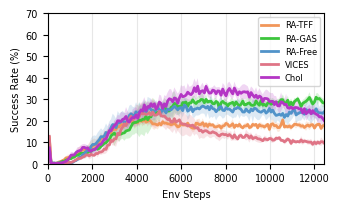

In [39]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate vs env steps — one mean+95%CI line per METHOD (seeds pooled over all grasp angles).
m = METRICS["success"]
fig = au.figure_by_method(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                          title=None, #f'{m["ylabel"]} by method',
                          ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "success_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/success_by_angle.svg


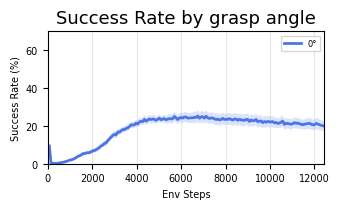

In [40]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate vs env steps — one mean+95%CI line per GRASP ANGLE (seeds pooled over all methods).
m = METRICS["success"]
fig = au.figure_by_angle(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                         title=f'{m["ylabel"]} by grasp angle',
                         ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "success_by_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/success_per_angle.svg


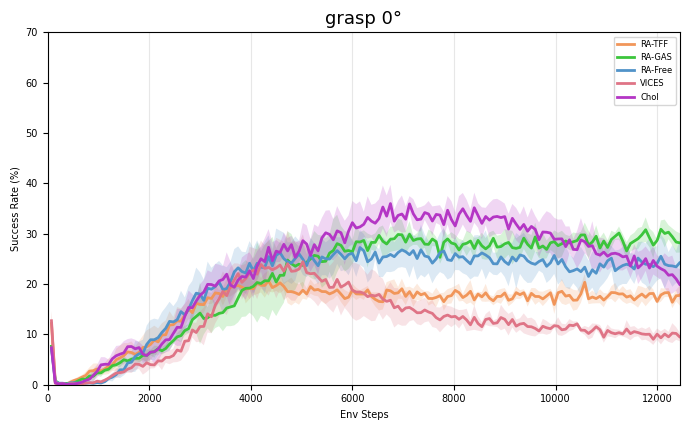

In [41]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Success rate vs env steps — one panel per GRASP ANGLE, methods overlaid within each single angle.
m = METRICS["success"]
au.DEFAULT_FIG_WIDTH *= 2
au.DEFAULT_FIG_HEIGHT *=2
fig = au.figure_per_angle_panels(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                                 suptitle=None, #f'{m["ylabel"]} — methods per grasp angle',
                                 ylim=m["ylim"], ci_clip=m["ci_clip"],
                                 smooth_window=SMOOTH_WINDOW, ncols=2)
au.save_figure(fig, "success_per_angle", STYLE)
plt.show()

## 6. Mean reward

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/reward_by_method.svg


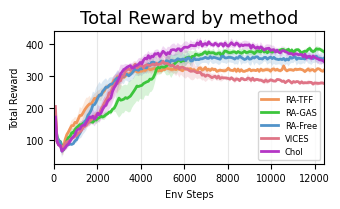

In [42]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward vs env steps — one mean+95%CI line per METHOD (seeds pooled over all grasp angles).
m = METRICS["reward"]
fig = au.figure_by_method(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                          title=f'{m["ylabel"]} by method',
                          ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "reward_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/reward_by_angle.svg


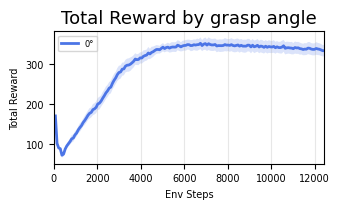

In [43]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward vs env steps — one mean+95%CI line per GRASP ANGLE (seeds pooled over all methods).
m = METRICS["reward"]
fig = au.figure_by_angle(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                         title=f'{m["ylabel"]} by grasp angle',
                         ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "reward_by_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/reward_per_angle.svg


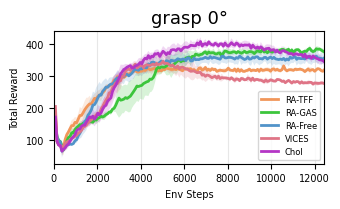

In [44]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Mean reward vs env steps — one panel per GRASP ANGLE, methods overlaid within each single angle.
m = METRICS["reward"]
fig = au.figure_per_angle_panels(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                                 suptitle=None, #f'{m["ylabel"]} — methods per grasp angle',
                                 ylim=m["ylim"], ci_clip=m["ci_clip"],
                                 smooth_window=SMOOTH_WINDOW, ncols=2)
au.save_figure(fig, "reward_per_angle", STYLE)
plt.show()

## 7. Average force

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/force_by_method.svg


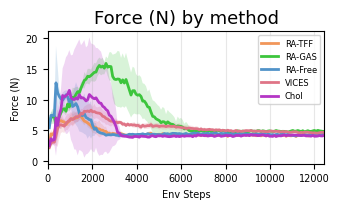

In [45]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force vs env steps — one mean+95%CI line per METHOD (seeds pooled over all grasp angles).
m = METRICS["force"]
fig = au.figure_by_method(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                          title=f'{m["ylabel"]} by method',
                          ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "force_by_method", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/force_by_angle.svg


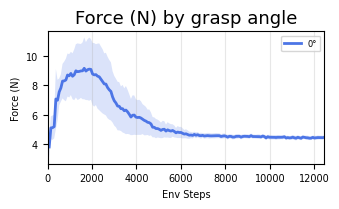

In [46]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force vs env steps — one mean+95%CI line per GRASP ANGLE (seeds pooled over all methods).
m = METRICS["force"]
fig = au.figure_by_angle(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                         title=f'{m["ylabel"]} by grasp angle',
                         ylim=m["ylim"], ci_clip=m["ci_clip"], smooth_window=SMOOTH_WINDOW)
au.save_figure(fig, "force_by_angle", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/curved_scribing_curved_v1/plots/iros_performance/force_per_angle.svg


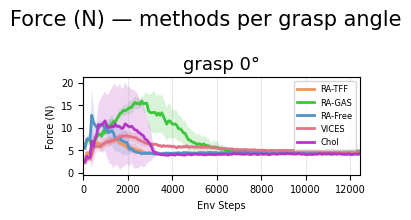

In [47]:
import importlib; importlib.reload(au)  # hot-reload analysis_utils (edits apply without re-loading data)
# Average force vs env steps — one panel per GRASP ANGLE, methods overlaid within each single angle.
m = METRICS["force"]
fig = au.figure_per_angle_panels(COL, m["tag"], STYLE, ylabel=m["ylabel"],
                                 suptitle=f'{m["ylabel"]} — methods per grasp angle',
                                 ylim=m["ylim"], ci_clip=m["ci_clip"],
                                 smooth_window=SMOOTH_WINDOW, ncols=2)
au.save_figure(fig, "force_per_angle", STYLE)
plt.show()